# 3. Preprocesamiento y Feature Engineering

En este notebook aplicamos las transformaciones justificadas por los hallazgos del EDA.


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os
import sys; sys.path.insert(0, '..')
from src.data_loader import load_raw
from src.preprocessing import engineer_features

df = load_raw('../data/raw/data_customers.csv')
print(f"Dataset original: {df.shape}")
df.head()


Dataset original: (9996, 13)


,fullVisitorId,channelGrouping,weekend_prop,hour,n_sessions,device.browser,device.deviceCategory,device.isMobile,device.operatingSystem,totals.hits,totals.pageviews,bounce_prop,trafficSource.medium
0,213131142648941,Direct,0.000000,22.0,1,Chrome,desktop,0.0,Macintosh,14.0,13.0,0.0,(none)
1,435324061339869,Referral,0.666667,21.0,3,Chrome,desktop,0.0,Macintosh,14.0,11.0,0.0,referral
2,562678147042735,Organic Search,0.000000,14.0,2,Chrome,desktop,0.0,Macintosh,12.5,10.5,0.0,organic
3,585708896049892,Referral,0.000000,20.0,1,Chrome,desktop,0.0,Linux,22.0,20.0,0.0,referral
4,670722016498267,Referral,0.000000,17.0,2,Chrome,desktop,0.0,Linux,9.5,9.5,0.0,referral


## 3.1 Variables Derivadas

Creamos features que capturan comportamiento a nivel de sesión, no solo agregados:

- **hits_per_session**: intensidad de interacción por visita
- **pageviews_per_session**: profundidad de navegación por visita
- **hits_per_pageview**: densidad de interacciones por página (mide si el usuario hace muchas acciones por página o navega superficialmente)
- **part_of_day**: discretización de hora en 4 bloques (mañana, tarde, noche, madrugada)


In [2]:
# Crear features derivadas
df['hits_per_session'] = df['totals.hits'] / df['n_sessions']
df['pageviews_per_session'] = df['totals.pageviews'] / df['n_sessions']
df['hits_per_pageview'] = df['totals.hits'] / df['totals.pageviews'].replace(0, np.nan)

# Part of day
df['part_of_day'] = pd.cut(df['hour'], bins=[-1, 6, 12, 18, 24],
                           labels=['madrugada', 'mañana', 'tarde', 'noche'])

print("Variables derivadas creadas:")
print(f"  hits_per_session: media={df['hits_per_session'].mean():.2f}")
print(f"  pageviews_per_session: media={df['pageviews_per_session'].mean():.2f}")
print(f"  hits_per_pageview: media={df['hits_per_pageview'].mean():.2f}")
print(f"  part_of_day: {df['part_of_day'].value_counts().to_dict()}")


Variables derivadas creadas:
  hits_per_session: media=15.22
  pageviews_per_session: media=12.01
  hits_per_pageview: media=1.22
  part_of_day: {'tarde': 4238, 'noche': 2997, 'madrugada': 1688, 'mañana': 1073}


## 3.2 Transformaciones: Clip P99 + Log1p


In [3]:
# Variables sesgadas a transformar
skewed_cols = ['n_sessions', 'totals.hits', 'totals.pageviews', 'hits_per_session', 'pageviews_per_session']

print("=== ANTES DE TRANSFORMAR ===")
for col in skewed_cols:
    print(f"  {col}: skew={df[col].skew():.2f}, kurt={df[col].kurtosis():.2f}")

# Clip al P99
for col in skewed_cols:
    p99 = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=p99)

# Log1p
for col in skewed_cols:
    df[f'log_{col}'] = np.log1p(df[col])

print("\n=== DESPUÉS DE LOG1P ===")
log_cols = [f'log_{c}' for c in skewed_cols]
for col in log_cols:
    print(f"  {col}: skew={df[col].skew():.2f}, kurt={df[col].kurtosis():.2f}")

print("\nResultado: skew baja de >5 a ~0, kurtosis de >60 a manejable.")


=== ANTES DE TRANSFORMAR ===
  n_sessions: skew=19.67, kurt=657.10
  totals.hits: skew=5.13, kurt=68.38
  totals.pageviews: skew=6.65, kurt=127.12
  hits_per_session: skew=5.41, kurt=73.96
  pageviews_per_session: skew=6.56, kurt=123.59

=== DESPUÉS DE LOG1P ===
  log_n_sessions: skew=0.88, kurt=0.31
  log_totals.hits: skew=-0.29, kurt=-0.16
  log_totals.pageviews: skew=-0.30, kurt=-0.15
  log_hits_per_session: skew=0.05, kurt=-1.02
  log_pageviews_per_session: skew=0.07, kurt=-1.07

Resultado: skew baja de >5 a ~0, kurtosis de >60 a manejable.


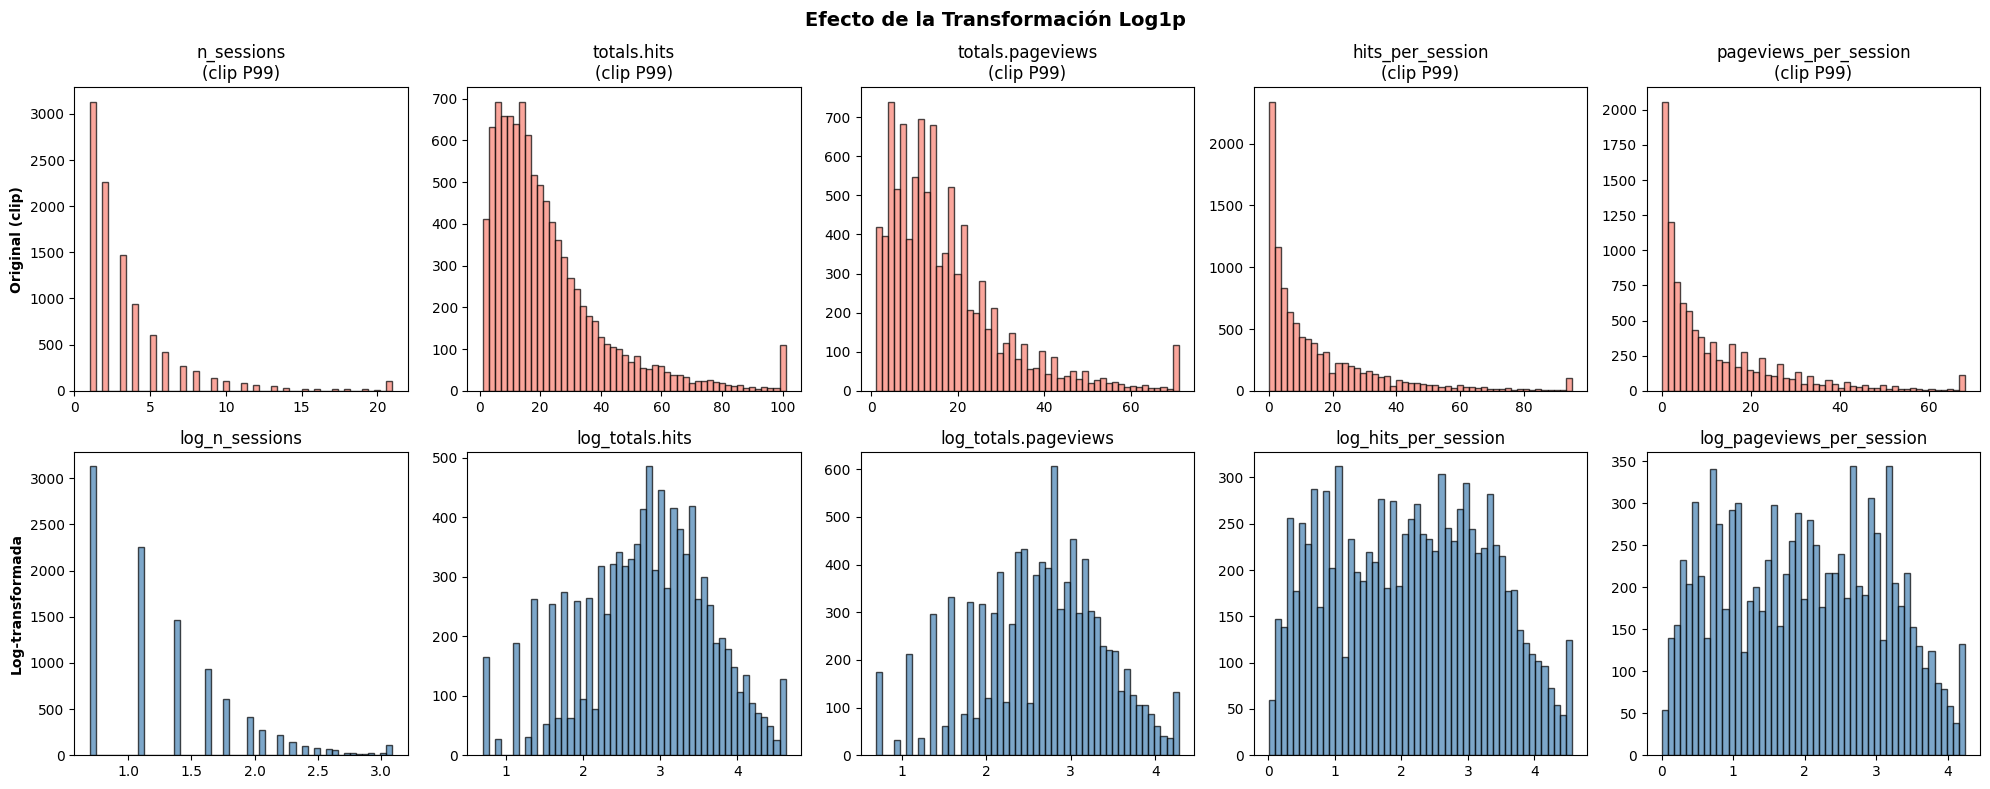

In [4]:
# Visualización antes/después
fig, axes = plt.subplots(2, len(skewed_cols), figsize=(20, 8))
for i, col in enumerate(skewed_cols):
    axes[0, i].hist(df[col], bins=50, color='salmon', edgecolor='black', alpha=0.7)
    axes[0, i].set_title(f'{col}\n(clip P99)')
    axes[1, i].hist(df[f'log_{col}'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[1, i].set_title(f'log_{col}')
axes[0, 0].set_ylabel('Original (clip)', fontweight='bold')
axes[1, 0].set_ylabel('Log-transformada', fontweight='bold')
plt.suptitle('Efecto de la Transformación Log1p', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/transformacion_log.png', dpi=150, bbox_inches='tight')
plt.show()


## 3.3 Agrupación de Categorías Raras


In [5]:
# Browser: Chrome, Safari, Firefox, Other
df['browser_top'] = df['device.browser'].apply(
    lambda x: x if x in ['Chrome', 'Safari', 'Firefox'] else 'Other')
print(f"browser_top: {df['browser_top'].value_counts().to_dict()}")

# OS: Macintosh, Windows, iOS, Android, Other
df['os_top'] = df['device.operatingSystem'].apply(
    lambda x: x if x in ['Macintosh', 'Windows', 'iOS', 'Android'] else 'Other')
print(f"os_top: {df['os_top'].value_counts().to_dict()}")

print("\nJustificación: evitar one-hot con columnas de <10 observaciones.")


browser_top: {'Chrome': 8937, 'Safari': 727, 'Other': 171, 'Firefox': 161}
os_top: {'Macintosh': 5551, 'Windows': 1991, 'Other': 1501, 'iOS': 519, 'Android': 434}

Justificación: evitar one-hot con columnas de <10 observaciones.


## 3.4 Eliminación de Variables Redundantes


In [6]:
# Eliminar trafficSource.medium (redundante con channelGrouping, V=0.98)
print(f"Eliminando trafficSource.medium (Cramer's V = 0.98 con channelGrouping)")
# No la borramos del df pero no la incluimos en la matriz de clustering


Eliminando trafficSource.medium (Cramer's V = 0.98 con channelGrouping)


## 3.5 Matriz Final para Clustering


In [7]:
# Variables numéricas para clustering (usamos las log-transformadas)
num_features = ['log_n_sessions', 'log_totals.hits', 'log_totals.pageviews',
                'bounce_prop', 'weekend_prop', 'log_hits_per_session',
                'log_pageviews_per_session', 'hour']

# Variables categóricas para one-hot
cat_features = ['channelGrouping', 'device.deviceCategory', 'part_of_day', 'browser_top', 'os_top']

# Escalado
scaler = StandardScaler()
X_num = pd.DataFrame(scaler.fit_transform(df[num_features]),
                     columns=num_features, index=df.index)

# One-hot encoding
X_cat = pd.get_dummies(df[cat_features], drop_first=False)

# Matriz final
X = pd.concat([X_num, X_cat], axis=1)
print(f"\nMatriz final para clustering: {X.shape[0]:,} visitantes × {X.shape[1]} columnas")
print(f"  {len(num_features)} numéricas escaladas")
print(f"  {X_cat.shape[1]} columnas one-hot de {len(cat_features)} categóricas")

# Guardar
df.to_pickle('../data/processed/df_processed.pkl')
pickle.dump(scaler, open('../models/scaler.pkl', 'wb'))
np.save('../models/X.npy', X.values)
print("\nArchivos guardados: df_processed.pkl, scaler.pkl, X.npy")



Matriz final para clustering: 9,996 visitantes × 32 columnas
  8 numéricas escaladas
  24 columnas one-hot de 5 categóricas

Archivos guardados: df_processed.pkl, scaler.pkl, X.npy
